<div class='alert alert-block alert-info"'>
<h1> An sdg4varselect example :</h1>

<h4> Variable selection and estimation in a joint model of logitic longitudinal data and survival data </h4>
</div>

In [2]:
import sdg4varselect.plot as sdgplt
import jax.numpy as jnp
import jax.random as jrd

### Dataset generation

First, let's generate a data set corresponding to a joint model of longitduinal logistic data and a Cox model.


$$ \left\{\begin{array}{rll}
            h(t|U_i) 
            &=h_{\theta_{base} }(t) \exp(\beta^T U_i + \alpha m(t,\varphi_i))
            \\ Y_{i,j} &= m(t_j; \varphi_i) + \varepsilon_{i,j}
            \\ \varphi_i \sim \mathcal N(\mu, \Gamma)   
            & ; ~\varepsilon_{i,j} \sim \mathcal N(0,\sigma^2).             
        \end{array}\right. ~ \forall i \in\{1,...,N\}, j\in\{1,...,J\}$$

censoring = 61%


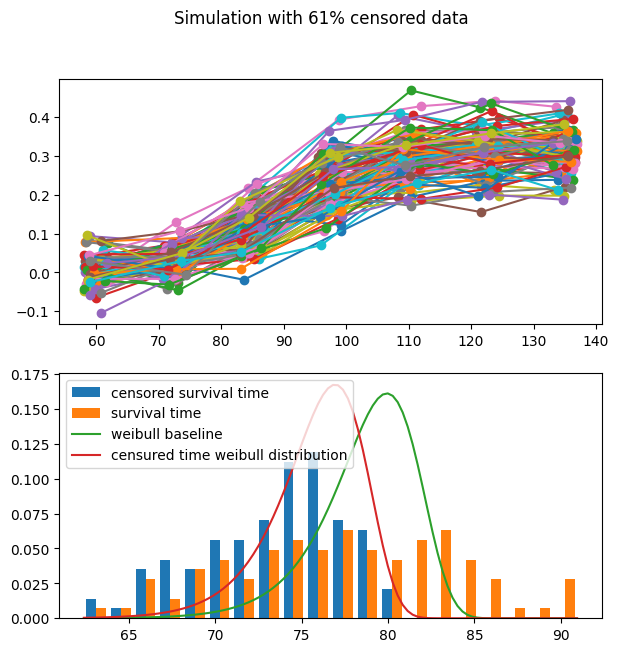

In [5]:
from sdg4varselect.logistic import Logistic_JM
from sdg4varselect.data_handler import Data_handler

model = Logistic_JM(N=100, J=7, DIM_HD=20)

# Simulation parameter
params_star = model.new_params(
    mu1=0.3,
    mu2=90.0,
    mu3=7.5,
    gamma2_1=0.0025,
    gamma2_2=20,
    sigma2=0.001,
    alpha=11.11,
    beta=jnp.concatenate([jnp.array([-2, -3, 3, 2]), jnp.zeros(shape=(16,))] )
)

obs, sim = model.sample(params_star, jrd.PRNGKey(0), weibull_censoring_loc=77)

dh = Data_handler()
dh.add_data(**obs)

_ = sdgplt.plot_sample(obs, sim, params_star, 77, 80, 35)

In [ ]:

multi_estim = [one_estim(jrd.PRNGKey(key), model, dh, lbd=None) for key in range(1)]
while NanError in multi_estim:
    multi_estim.remove(NanError)

# === PLOT === #
from sdg4varselect.plot import (
    plot_theta,
    plot_theta_HD,
)

params_star = get_params_star(model.DIM_HD)

plot_theta(multi_estim, model.DIM_LD, params_star, model.params_names)
plot_theta_HD(multi_estim, model.DIM_LD, params_star, model.params_names)

try an estimation on the data set with the SPG-FIM algorithm

In [ ]:
from sdg4varselect.algo import SPG_FIM, NanError, estim_res

# algorithm settings
algo_settings = SPG_FIM.settings(
    step_size_grad={
        "learning_rate": 1e-8,
        "preheating": 400,
        "heating": 600,
        "max": 0.9,
    },
    step_size_approx_sto={
        "learning_rate": 1e-8,
        "preheating": 400,
        "heating": None,
        "max": 1,
    },
    step_size_fisher={
        "learning_rate": 1e-8,
        "preheating": 400,
        "heating": None,
        "max": 0.9,
    },
    max_iter=2000,
)

# for only estimation we set lambda = None 
algo = SPG_FIM(jrd.PRNGKey(0), dh, algo_settings, lbd=None)


PRNGKey_theta, PRNGKey_estim, PRNGKey_likelihoohd = jrd.split(PRNGKey, 3)
    theta0 = 0.2 * jrd.normal(PRNGKey_theta, shape=(model.parametrization.size,))



multi_estim = [one_estim(jrd.PRNGKey(key), model, dh, lbd=None) for key in range(1)]
while NanError in multi_estim:
    multi_estim.remove(NanError)

# === PLOT === #
from sdg4varselect.plot import (
    plot_theta,
    plot_theta_HD,
)

params_star = get_params_star(model.DIM_HD)

plot_theta(multi_estim, model.DIM_LD, params_star, model.params_names)
plot_theta_HD(multi_estim, model.DIM_LD, params_star, model.params_names)